# Video Marker Tracking

Process MP4 videos to track blue markers (hip, knee, ankle) and export tracking data.

**Prerequisites**: Run `01_color_tuning.ipynb` first to create your detection config.

In [2]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

from src.config import BlueDetectionConfig
from src.tracker import BlueMarkerDetector, VideoMarkerTracker

%matplotlib inline

## 1. Load Configuration

In [4]:
# Load the config you tuned in the color tuning notebook
config_path = "../data/detection_config.json"

try:
    config = BlueDetectionConfig.load(config_path)
    print("Loaded configuration:")
    print(config)
except FileNotFoundError:
    print(f"Config not found at {config_path}")
    print("Using default configuration. Run 01_color_tuning.ipynb first!")
    config = BlueDetectionConfig()

Loaded configuration:
BlueDetectionConfig(
  HSV Lower: (90, 200, 50)
  HSV Upper: (130, 255, 255)
  Min Area: 500
  Max Area: 30000
  Circularity: 0.3
)


## 2. Setup Paths

In [6]:
# Input video path
VIDEO_PATH = "../data/jump-threequarters.mp4"  # <-- UPDATE THIS

# Output paths
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

video_name = Path(VIDEO_PATH).stem
CSV_OUTPUT = OUTPUT_DIR / f"{video_name}_tracking.csv"
NPY_OUTPUT = OUTPUT_DIR / f"{video_name}_tracking.npy"
VIDEO_OUTPUT = OUTPUT_DIR / f"{video_name}_annotated.mp4"

print(f"Input: {VIDEO_PATH}")
print(f"CSV output: {CSV_OUTPUT}")
print(f"NPY output: {NPY_OUTPUT}")
print(f"Video output: {VIDEO_OUTPUT}")

Input: ../data/jump-threequarters.mp4
CSV output: ../output/jump-threequarters_tracking.csv
NPY output: ../output/jump-threequarters_tracking.npy
Video output: ../output/jump-threequarters_annotated.mp4


## 3. Video Info

In [8]:
cap = cv2.VideoCapture(VIDEO_PATH)

if cap.isOpened():
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = total_frames / fps
    
    print(f"Video Properties:")
    print(f"  Resolution: {width} x {height}")
    print(f"  FPS: {fps}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {duration:.2f} seconds")
    cap.release()
else:
    print(f"ERROR: Could not open video at {VIDEO_PATH}")

Video Properties:
  Resolution: 1216 x 2160
  FPS: 30.042290300962122
  Total frames: 130
  Duration: 4.33 seconds


## 4. Process Video

In [10]:
# Create tracker
tracker = VideoMarkerTracker(config)

# Progress bar callback
pbar = None
def progress_callback(frame_num, total):
    global pbar
    if pbar is None:
        pbar = tqdm(total=total, desc="Processing")
    pbar.update(1)

# Process the video
print("Processing video...")
results = tracker.process_video(
    VIDEO_PATH,
    max_frames=None,  # Set to e.g. 100 for quick test
    progress_callback=progress_callback
)

if pbar:
    pbar.close()

print(f"\nProcessed {len(results)} frames")

Processing video...


Processing:   0%|          | 0/130 [00:00<?, ?it/s]


Processed 130 frames


## 5. Detection Quality Summary

In [12]:
# Count detection success rates
complete_frames = sum(1 for r in results if r.is_complete)
hip_detected = sum(1 for r in results if r.hip is not None)
knee_detected = sum(1 for r in results if r.knee is not None)
ankle_detected = sum(1 for r in results if r.ankle is not None)

total = len(results)

print(f"Detection Summary:")
print(f"  Complete (all 3 markers): {complete_frames}/{total} ({100*complete_frames/total:.1f}%)")
print(f"  Hip detected: {hip_detected}/{total} ({100*hip_detected/total:.1f}%)")
print(f"  Knee detected: {knee_detected}/{total} ({100*knee_detected/total:.1f}%)")
print(f"  Ankle detected: {ankle_detected}/{total} ({100*ankle_detected/total:.1f}%)")

Detection Summary:
  Complete (all 3 markers): 130/130 (100.0%)
  Hip detected: 130/130 (100.0%)
  Knee detected: 130/130 (100.0%)
  Ankle detected: 130/130 (100.0%)


## 6. Export Data

In [14]:
# Export to CSV
tracker.export_to_csv(CSV_OUTPUT)
print(f"CSV saved to: {CSV_OUTPUT}")

# Export to NumPy
tracking_array = tracker.export_to_numpy()
np.save(NPY_OUTPUT, tracking_array)
print(f"NumPy array saved to: {NPY_OUTPUT}")
print(f"Array shape: {tracking_array.shape}")

CSV saved to: ../output/jump-threequarters_tracking.csv
NumPy array saved to: ../output/jump-threequarters_tracking.npy
Array shape: (130, 9)


In [15]:
# Load and preview CSV
df = pd.read_csv(CSV_OUTPUT)
print(f"\nDataFrame shape: {df.shape}")
df.head(10)


DataFrame shape: (130, 10)


,frame,hip_x,hip_y,hip_radius,knee_x,knee_y,knee_radius,ankle_x,ankle_y,ankle_radius
0,0,560.221985,1113.035645,51.643917,630.130798,1510.401855,47.599903,572.5,1860.5,46.308846
1,1,560.128662,1113.925537,51.768284,630.632141,1510.931763,47.743111,572.5,1860.5,46.308846
2,2,559.764343,1114.535889,51.915577,631.172058,1511.567383,47.875885,572.5,1860.0,46.618229
3,3,560.921875,1115.130249,51.705505,631.537415,1511.680664,47.635731,572.5,1860.0,46.618229
4,4,562.673889,1115.543457,51.844898,631.643127,1511.713379,47.566555,572.5,1860.5,46.930901
5,5,564.622925,1115.311035,52.230328,631.791260,1511.244385,47.950211,572.5,1860.5,46.930901
6,6,564.903320,1115.440063,51.921978,632.500000,1512.000000,48.127533,572.5,1861.0,46.618229
7,7,563.767822,1115.597046,51.892914,634.880432,1512.715698,48.067852,572.5,1861.0,46.618229
8,8,561.029419,1116.259521,51.873631,636.259033,1513.130371,47.321293,573.5,1860.5,46.157440
9,9,556.749756,1118.159180,52.688057,638.609985,1514.000488,47.688118,575.5,1858.5,46.157440


## 7. Visualize Tracking Data

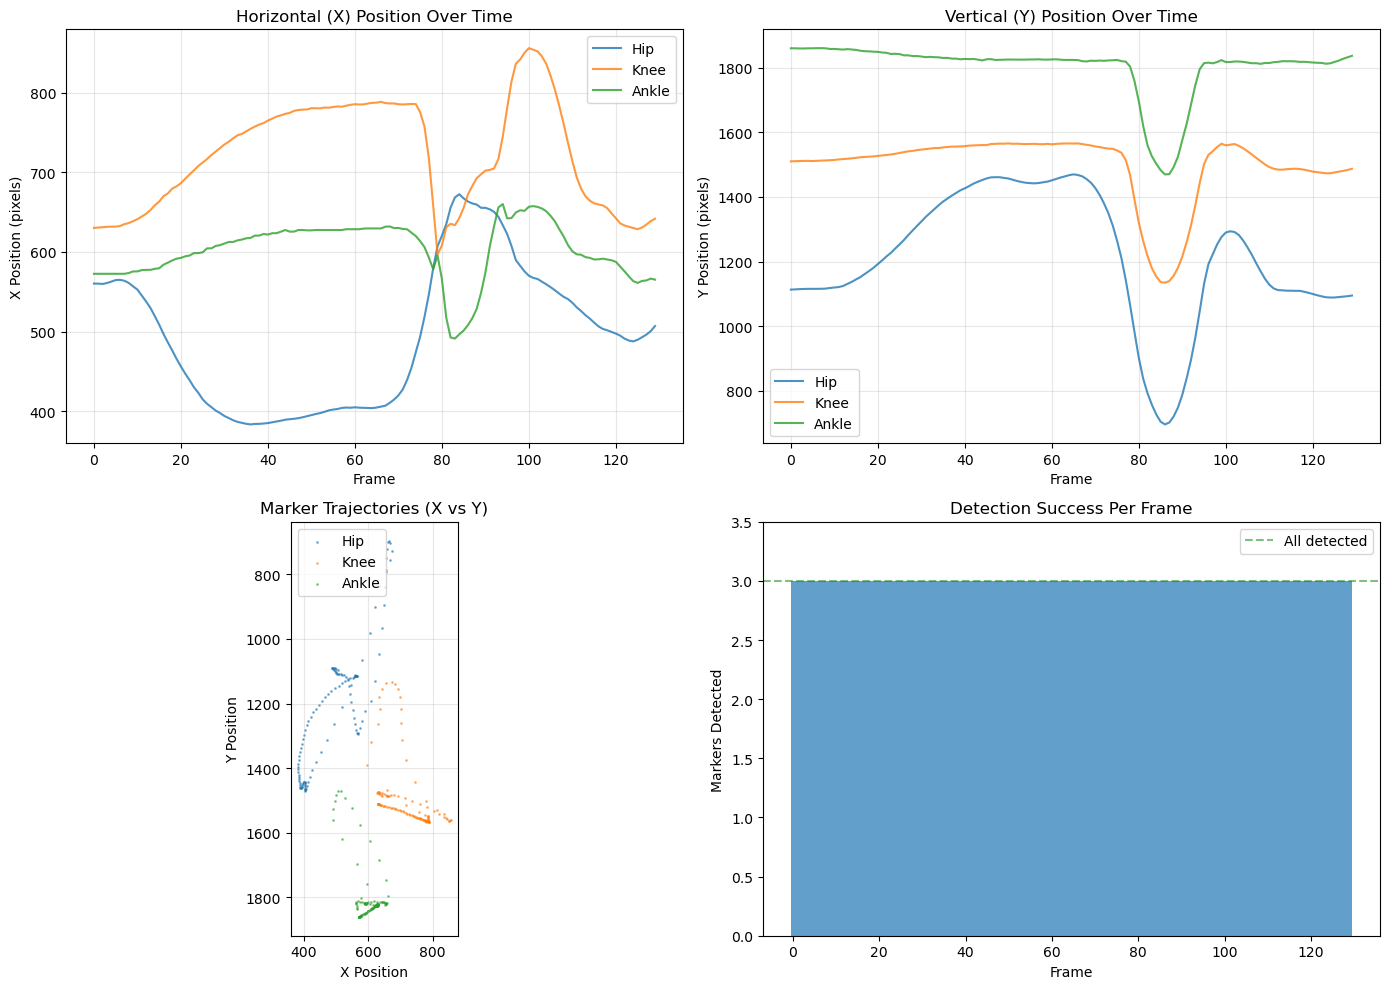

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# X positions over time
ax = axes[0, 0]
ax.plot(df['frame'], df['hip_x'], label='Hip', alpha=0.8)
ax.plot(df['frame'], df['knee_x'], label='Knee', alpha=0.8)
ax.plot(df['frame'], df['ankle_x'], label='Ankle', alpha=0.8)
ax.set_xlabel('Frame')
ax.set_ylabel('X Position (pixels)')
ax.set_title('Horizontal (X) Position Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Y positions over time
ax = axes[0, 1]
ax.plot(df['frame'], df['hip_y'], label='Hip', alpha=0.8)
ax.plot(df['frame'], df['knee_y'], label='Knee', alpha=0.8)
ax.plot(df['frame'], df['ankle_y'], label='Ankle', alpha=0.8)
ax.set_xlabel('Frame')
ax.set_ylabel('Y Position (pixels)')
ax.set_title('Vertical (Y) Position Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Trajectory plot (X vs Y)
ax = axes[1, 0]
ax.scatter(df['hip_x'], df['hip_y'], s=1, alpha=0.5, label='Hip')
ax.scatter(df['knee_x'], df['knee_y'], s=1, alpha=0.5, label='Knee')
ax.scatter(df['ankle_x'], df['ankle_y'], s=1, alpha=0.5, label='Ankle')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Marker Trajectories (X vs Y)')
ax.legend()
ax.invert_yaxis()  # Image coordinates have Y increasing downward
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Detection success per frame
ax = axes[1, 1]
markers_per_frame = df[['hip_x', 'knee_x', 'ankle_x']].notna().sum(axis=1)
ax.bar(df['frame'], markers_per_frame, width=1.0, alpha=0.7)
ax.set_xlabel('Frame')
ax.set_ylabel('Markers Detected')
ax.set_title('Detection Success Per Frame')
ax.set_ylim(0, 3.5)
ax.axhline(y=3, color='green', linestyle='--', alpha=0.5, label='All detected')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{video_name}_analysis.png", dpi=150)
plt.show()

## 8. Create Annotated Video (Optional)

In [19]:
# This may take a while for long videos
CREATE_ANNOTATED_VIDEO = True  # Set to False to skip

if CREATE_ANNOTATED_VIDEO:
    print(f"Creating annotated video...")
    tracker.create_annotated_video(
        VIDEO_PATH, 
        str(VIDEO_OUTPUT),
        show_mask=False  # Set True to show detection mask overlay
    )
    print(f"Annotated video saved to: {VIDEO_OUTPUT}")
else:
    print("Skipping annotated video creation")

Creating annotated video...
Annotated video saved to: ../output/jump-threequarters_annotated.mp4


## 9. Calculate Joint Angles

In [21]:
def calculate_knee_angle(hip, knee, ankle):
    """
    Calculate the knee angle (in degrees) given hip, knee, ankle positions.
    
    Returns angle at the knee joint (180 = straight leg).
    """
    # Vectors from knee to hip and knee to ankle
    v1 = np.array([hip[0] - knee[0], hip[1] - knee[1]])
    v2 = np.array([ankle[0] - knee[0], ankle[1] - knee[1]])
    
    # Calculate angle using dot product
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cos_angle = np.clip(cos_angle, -1, 1)  # Handle numerical errors
    angle = np.degrees(np.arccos(cos_angle))
    
    return angle

# Calculate knee angle for each frame
angles = []
for _, row in df.iterrows():
    if pd.notna(row['hip_x']) and pd.notna(row['knee_x']) and pd.notna(row['ankle_x']):
        hip = (row['hip_x'], row['hip_y'])
        knee = (row['knee_x'], row['knee_y'])
        ankle = (row['ankle_x'], row['ankle_y'])
        angle = calculate_knee_angle(hip, knee, ankle)
        angles.append(angle)
    else:
        angles.append(np.nan)

df['knee_angle'] = angles

# Save updated CSV
df.to_csv(CSV_OUTPUT, index=False)
print(f"Updated CSV with knee angles saved to: {CSV_OUTPUT}")

Updated CSV with knee angles saved to: ../output/jump-threequarters_tracking.csv


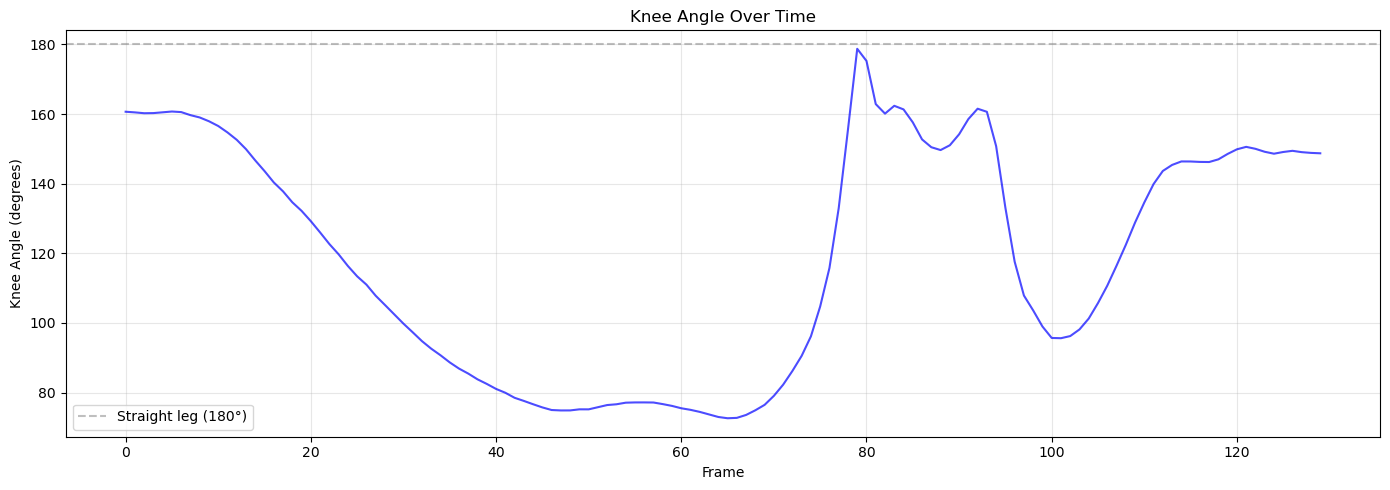


Knee Angle Statistics:
  Min: 72.6°
  Max: 178.8°
  Mean: 118.8°
  Range: 106.1°


In [22]:
# Plot knee angle over time
plt.figure(figsize=(14, 5))
plt.plot(df['frame'], df['knee_angle'], 'b-', alpha=0.7)
plt.xlabel('Frame')
plt.ylabel('Knee Angle (degrees)')
plt.title('Knee Angle Over Time')
plt.axhline(y=180, color='gray', linestyle='--', alpha=0.5, label='Straight leg (180°)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{video_name}_knee_angle.png", dpi=150)
plt.show()

# Summary statistics
print(f"\nKnee Angle Statistics:")
print(f"  Min: {df['knee_angle'].min():.1f}°")
print(f"  Max: {df['knee_angle'].max():.1f}°")
print(f"  Mean: {df['knee_angle'].mean():.1f}°")
print(f"  Range: {df['knee_angle'].max() - df['knee_angle'].min():.1f}°")

## 10. Batch Processing (Multiple Videos)

In [24]:
def process_video_file(video_path, config, output_dir):
    """
    Process a single video file and save results.
    """
    video_path = Path(video_path)
    output_dir = Path(output_dir)
    video_name = video_path.stem
    
    print(f"\nProcessing: {video_path.name}")
    
    tracker = VideoMarkerTracker(config)
    
    # Process with progress bar
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    
    with tqdm(total=total_frames, desc=video_name) as pbar:
        results = tracker.process_video(
            str(video_path),
            progress_callback=lambda f, t: pbar.update(1)
        )
    
    # Save results
    csv_path = output_dir / f"{video_name}_tracking.csv"
    tracker.export_to_csv(csv_path)
    
    # Calculate detection rate
    complete = sum(1 for r in results if r.is_complete)
    rate = 100 * complete / len(results)
    
    print(f"  Saved: {csv_path}")
    print(f"  Detection rate: {rate:.1f}%")
    
    return csv_path, rate

# Example: Process all MP4 files in a directory
# video_dir = Path("../data/videos")
# video_files = list(video_dir.glob("*.mp4"))
# 
# for video_file in video_files:
#     process_video_file(video_file, config, OUTPUT_DIR)